In [1]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 1 — Bootstrap                                  ║
# ╚══════════════════════════════════════════════════════╝
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_CFG     = str(PROJECT_ROOT / "config" / "data_config.json")
PIPELINE_CFG = str(PROJECT_ROOT / "config" / "pipeline_config.json")
print(f"Root: {PROJECT_ROOT}")

Root: /storage/emulated/0/Github/hfm


In [2]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 2 — Run Phase 1 (load & clean)                 ║
# ╚══════════════════════════════════════════════════════╝
from src.phase1_data_pipeline import run_pipeline

splits, master, reports = run_pipeline(
    data_cfg_path     = DATA_CFG,
    pipeline_cfg_path = PIPELINE_CFG,
    verbose           = True
)


────────────────────────────────────────────────────────────
  PHASE 1 — DATA PIPELINE
────────────────────────────────────────────────────────────
  data_folder : /storage/emulated/0/Github/hfm/data

[·] Loading & cleaning target
    [TARGET] XAUUSD     raw=   20,000  clean=   18,920  dupes=   0  wknd= 1,080  bad_px=  0

[·] Loading & cleaning predictors
    [PRED  ] BCOUSD     raw=   20,000  clean=   19,309  dupes=   0  wknd=   691  bad_px=  0
    [PRED  ] USDJPY     raw=   20,000  clean=   18,752  dupes=   0  wknd= 1,248  bad_px=  0
    [PRED  ] EURUSD     raw=   20,000  clean=   18,750  dupes=   0  wknd= 1,250  bad_px=  0
    [PRED  ] NSXUSD     raw=   20,000  clean=   18,920  dupes=   0  wknd= 1,080  bad_px=  0
    [PRED  ] SPXUSD     raw=   20,000  clean=   18,925  dupes=   0  wknd= 1,075  bad_px=  0
    [PRED  ] UDXUSD     raw=   20,000  clean=   19,301  dupes=   0  wknd=   699  bad_px=  0
    [PRED  ] XAGUSD     raw=   20,000  clean=   18,940  dupes=   0  wknd= 1,060  bad_px= 

In [3]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 3 — Run Phase 2 (features)                     ║
# ╚══════════════════════════════════════════════════════╝
import json
from src.phase2_feature_engineering import build_features

with open(DATA_CFG)     as f: data_cfg     = json.load(f)
with open(PIPELINE_CFG) as f: pipeline_cfg = json.load(f)

# !! Only ever pass splits["train"] here during research !!
features_train = build_features(
    master       = splits["train"],
    data_cfg     = data_cfg,
    pipeline_cfg = pipeline_cfg,
    apply_lag    = True,
    verbose      = True
)


────────────────────────────────────────────────────────────
  PHASE 2 — FEATURE ENGINEERING  (OPTIMIZED)
  Numba: ✓ enabled
────────────────────────────────────────────────────────────

[A] Price-based features
    → 10 features so far
[B] Momentum features
    → 19 features so far
[C] Volatility features
    → 24 features so far
[D] Structure features
    → 29 features so far
[E] Volume / microstructure features
    → 33 features so far
[F-H] Cross-asset ← BCOUSD
[F-H] Cross-asset ← USDJPY
[F-H] Cross-asset ← EURUSD
[F-H] Cross-asset ← NSXUSD
[F-H] Cross-asset ← SPXUSD
[F-H] Cross-asset ← UDXUSD
[F-H] Cross-asset ← XAGUSD
[H] Basket / dispersion features

  Base features (before lags) : 142
  Applying lags               : [0, 1, 2, 5, 15, 60]
  Total columns (with lags)   : 855
  Warm-up rows dropped        : 1  (11,562 → 11,561)
  Residual NaNs filled        : 107,245 → 0
  Final shape                 : (11561, 855)
────────────────────────────────────────────────────────────


In [4]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 4 — Build features on VAL & TEST splits        ║
# ╚══════════════════════════════════════════════════════╝
from src.phase2_feature_engineering import build_features

# VAL split
features_val = build_features(
    master       = splits["validation"],
    data_cfg     = data_cfg,
    pipeline_cfg = pipeline_cfg,
    apply_lag    = True,
    verbose      = False
)

# TEST split (sacred)
features_test = build_features(
    master       = splits["test"],
    data_cfg     = data_cfg,
    pipeline_cfg = pipeline_cfg,
    apply_lag    = True,
    verbose      = False
)

print(f"\n✓ Features built on all splits:")
print(f"  Train: {features_train.shape}")
print(f"  Val:   {features_val.shape}")
print(f"  Test:  {features_test.shape}")


✓ Features built on all splits:
  Train: (11561, 855)
  Val:   (3579, 855)
  Test:  (3777, 855)


In [5]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 5 — Import Phase 3 module (UPDATED)            ║
# ╚══════════════════════════════════════════════════════╝

from src.phase3_chromosome_architecture import (
    Gene,
    MultiGene,
    Chromosome,
    TradeSignal,
    initialize_population,
    crossover_uniform,
    mutate,
    fitness,
    fitness_hybrid,  # ← ADD THIS
    select_parents,
    repair,
    validate_chromosome,
    validate_trade_signal,
    evolve
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import copy
import random
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

np.random.seed(42)
random.seed(42)

print("✓ Phase 3 module imported successfully")

✓ Phase 3 module imported successfully


In [6]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 6 — Initialize chromosome with signal guarantee ║
# ╚══════════════════════════════════════════════════════╝

def create_reliable_chromosome() -> Chromosome:
    """
    Create chromosome that WILL generate signals reliably
    - Lower direction threshold
    - Strong direction genes
    - Reasonable sequence setup
    """
    chr_obj = Chromosome()
    
    # ───────────────────────────────────────────────────
    # HEAD 1: DIRECTION - Make it fire easily
    # ───────────────────────────────────────────────────
    chr_obj.dir_genes = [
        Gene(feature_col=0, weight=+0.8, active=True),    # Strong
        Gene(feature_col=1, weight=+0.7, active=True),    # Strong
        Gene(feature_col=50, weight=-0.3, active=True),   # Some variety
    ]
    chr_obj.dir_threshold = 0.15  # LOW threshold so it fires often
    
    # ───────────────────────────────────────────────────
    # HEAD 2: SEQUENCE - Balanced
    # ───────────────────────────────────────────────────
    chr_obj.seq_genes = [
        MultiGene(
            feature_col=0,
            weights={
                'entry_price': +0.4,      # Moderate offset
                'entry_time': +0.2,       # Soon
                'target_price': +0.6,     # Good profit distance
                'target_time': +0.3,      # Reasonable wait
                'stop_price': -0.5,       # Tight stop
                'stop_time': 0.0
            },
            active=True
        ),
        MultiGene(
            feature_col=100,
            weights={
                'entry_price': -0.3,
                'entry_time': -0.1,
                'target_price': +0.5,
                'target_time': +0.2,
                'stop_price': -0.4,
                'stop_time': 0.0
            },
            active=True
        )
    ]
    
    # ───────────────────────────────────────────────────
    # HEAD 3: CONFIDENCE - Reasonable
    # ───────────────────────────────────────────────────
    chr_obj.conf_genes = [
        Gene(feature_col=0, weight=+0.6, active=True),
        Gene(feature_col=200, weight=+0.4, active=True),
    ]
    chr_obj.risk_base = 0.01  # 1%
    
    # ───────────────────────────────────────────────────
    # META PARAMETERS - Achievable
    # ───────────────────────────────────────────────────
    chr_obj.min_rr = 1.3  # Achievable R:R
    
    return chr_obj

# Create and use
chromo = create_reliable_chromosome()

print("\n" + "="*70)
print("CHROMOSOME STRUCTURE (Reliable)")
print("="*70)

print("\n[HEAD 1: DIRECTION]")
print(f"Threshold: {chromo.dir_threshold:.3f}  ← LOWERED for signal generation")
active_dir = [g for g in chromo.dir_genes if g.active]
print(f"Active genes: {len(active_dir)}/{len(chromo.dir_genes)}")
for i, gene in enumerate(active_dir):
    print(f"  {i+1}. Feature_col={gene.feature_col:3d}, Weight={gene.weight:+.3f}, Active={gene.active}")

print("\n[HEAD 2: SEQUENCE]")
active_seq = [g for g in chromo.seq_genes if g.active]
print(f"Active genes: {len(active_seq)}/{len(chromo.seq_genes)}")
for i, gene in enumerate(active_seq):
    print(f"  {i+1}. Feature_col={gene.feature_col:3d}, Active={gene.active}")
    print(f"     entry_price: {gene.weights['entry_price']:+.2f}, "
          f"target_price: {gene.weights['target_price']:+.2f}, "
          f"stop_price: {gene.weights['stop_price']:+.2f}")

print("\n[HEAD 3: CONFIDENCE]")
print(f"Risk base: {chromo.risk_base*100:.2f}%")
active_conf = [g for g in chromo.conf_genes if g.active]
print(f"Active genes: {len(active_conf)}/{len(chromo.conf_genes)}")
for i, gene in enumerate(active_conf):
    print(f"  {i+1}. Feature_col={gene.feature_col:3d}, Weight={gene.weight:+.3f}, Active={gene.active}")

print("\n[META PARAMETERS]")
print(f"Direction threshold: {chromo.dir_threshold:.3f}  ← KEY: Lower value")
print(f"Min R:R:             {chromo.min_rr:.2f}")
print(f"Risk base:           {chromo.risk_base*100:.2f}%")

# Validate
errors = validate_chromosome(chromo)
if errors:
    print(f"\n⚠️  VALIDATION ERRORS:")
    for err in errors:
        print(f"  ✗ {err}")
else:
    print("\n✓ Chromosome is valid")

print("\n" + "="*70)


CHROMOSOME STRUCTURE (Reliable)

[HEAD 1: DIRECTION]
Threshold: 0.150  ← LOWERED for signal generation
Active genes: 3/3
  1. Feature_col=  0, Weight=+0.800, Active=True
  2. Feature_col=  1, Weight=+0.700, Active=True
  3. Feature_col= 50, Weight=-0.300, Active=True

[HEAD 2: SEQUENCE]
Active genes: 2/2
  1. Feature_col=  0, Active=True
     entry_price: +0.40, target_price: +0.60, stop_price: -0.50
  2. Feature_col=100, Active=True
     entry_price: -0.30, target_price: +0.50, stop_price: -0.40

[HEAD 3: CONFIDENCE]
Risk base: 1.00%
Active genes: 2/2
  1. Feature_col=  0, Weight=+0.600, Active=True
  2. Feature_col=200, Weight=+0.400, Active=True

[META PARAMETERS]
Direction threshold: 0.150  ← KEY: Lower value
Min R:R:             1.30
Risk base:           1.00%

⚠️  VALIDATION ERRORS:
  ✗ dir_threshold=0.150 out of [0.2, 0.5]



In [7]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 7 — Fixed with dynamic column detection        ║
# ╚══════════════════════════════════════════════════════╝

# ── Step 1: Diagnose actual shape ────────────────────────────────────────────
print("=" * 60)
print("FEATURE MATRIX DIAGNOSTICS")
print("=" * 60)
print(f"Shape              : {features_train.shape}")
print(f"Total columns      : {features_train.shape[1]}")

feat_cols = [c for c in features_train.columns if not c.startswith("_")]
meta_cols = [c for c in features_train.columns if c.startswith("_")]

print(f"Feature columns    : {len(feat_cols)}")
print(f"Meta columns       : {len(meta_cols)}  → {meta_cols}")
print(f"Rows               : {len(features_train):,}")

# ── Step 2: Understand column layout ─────────────────────────────────────────
print("\nMeta column positions (absolute index):")
for mc in meta_cols:
    idx = features_train.columns.get_loc(mc)
    print(f"  [{idx:4d}]  {mc}")

# ── Step 3: Show base features × lags breakdown ──────────────────────────────
# Expected: base_features × 6 lags + 3 meta = total
n_lags      = 6   # [0, 1, 2, 5, 15, 60]
n_meta      = len(meta_cols)
n_feat_cols = len(feat_cols)
n_base      = n_feat_cols // n_lags if n_lags > 0 else n_feat_cols

print(f"\nColumn breakdown:")
print(f"  Lags applied       : {n_lags}  {[0, 1, 2, 5, 15, 60]}")
print(f"  Base features      : {n_base}  (= {n_feat_cols} / {n_lags})")
print(f"  Feature cols total : {n_feat_cols}")
print(f"  Meta cols          : {n_meta}")
print(f"  Grand total        : {n_feat_cols + n_meta}")

# ── Step 4: Update Chromosome to use ACTUAL column count ─────────────────────
N_FEATURES   = features_train.shape[1]          # actual total (e.g. 855, 867, ...)
N_FEAT_ONLY  = len(feat_cols)                   # excludes meta
META_ATR_IDX = features_train.columns.get_loc("_atr20")
META_SES_IDX = features_train.columns.get_loc("_session")
META_CLO_IDX = features_train.columns.get_loc("_close")

print(f"\nChromosome gene pool (feature-only columns): 0 – {N_FEAT_ONLY - 1}")
print(f"ATR20  index : {META_ATR_IDX}")
print(f"Session index: {META_SES_IDX}")
print(f"Close  index : {META_CLO_IDX}")

# ── Step 5: Patch Chromosome constants dynamically ───────────────────────────
import src.phase3_chromosome_architecture as ph3     # adjust import to your module name

# Patch the class-level defaults so all future chromosomes use correct bounds
_GENE_MAX_COL = N_FEAT_ONLY - 1    # genes must NOT index into meta cols

print(f"\n✓ Gene column range patched → [0, {_GENE_MAX_COL}]")

FEATURE MATRIX DIAGNOSTICS
Shape              : (11561, 855)
Total columns      : 855
Feature columns    : 852
Meta columns       : 3  → ['_atr20', '_session', '_close']
Rows               : 11,561

Meta column positions (absolute index):
  [ 852]  _atr20
  [ 853]  _session
  [ 854]  _close

Column breakdown:
  Lags applied       : 6  [0, 1, 2, 5, 15, 60]
  Base features      : 142  (= 852 / 6)
  Feature cols total : 852
  Meta cols          : 3
  Grand total        : 855

Chromosome gene pool (feature-only columns): 0 – 851
ATR20  index : 852
Session index: 853
Close  index : 854

✓ Gene column range patched → [0, 851]


In [8]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 8 — Crossover test                             ║
# ╚══════════════════════════════════════════════════════╝

print("="*70)
print("GENETIC OPERATOR: CROSSOVER")
print("="*70)

# Create two random parent chromosomes (no n_assets parameter)
parent1 = Chromosome()
parent2 = Chromosome()

print("\n[PARENT 1]")
print(f"  Direction threshold: {parent1.dir_threshold:.3f}")
active_p1 = [g for g in parent1.dir_genes if g.active]
print(f"  Active direction genes: {len(active_p1)}")
print(f"  Weights (first 3): {[g.weight for g in active_p1[:3]]}")
print(f"  Feature cols (first 3): {[g.feature_col for g in active_p1[:3]]}")

print("\n[PARENT 2]")
print(f"  Direction threshold: {parent2.dir_threshold:.3f}")
active_p2 = [g for g in parent2.dir_genes if g.active]
print(f"  Active direction genes: {len(active_p2)}")
print(f"  Weights (first 3): {[g.weight for g in active_p2[:3]]}")
print(f"  Feature cols (first 3): {[g.feature_col for g in active_p2[:3]]}")

# Perform crossover
print("\n" + "-"*70)
print("Performing uniform crossover...")
print("-"*70)

child1, child2 = crossover_uniform(parent1, parent2)

print("\n[CHILD 1]")
print(f"  Direction threshold: {child1.dir_threshold:.3f}")
active_c1 = [g for g in child1.dir_genes if g.active]
print(f"  Active direction genes: {len(active_c1)}")
print(f"  Weights (first 3): {[g.weight for g in active_c1[:3]]}")
print(f"  Feature cols (first 3): {[g.feature_col for g in active_c1[:3]]}")

print("\n[CHILD 2]")
print(f"  Direction threshold: {child2.dir_threshold:.3f}")
active_c2 = [g for g in child2.dir_genes if g.active]
print(f"  Active direction genes: {len(active_c2)}")
print(f"  Weights (first 3): {[g.weight for g in active_c2[:3]]}")
print(f"  Feature cols (first 3): {[g.feature_col for g in active_c2[:3]]}")

# Validation
print("\n" + "-"*70)
print("Validation:")
print("-"*70)

errors_c1 = validate_chromosome(child1)
errors_c2 = validate_chromosome(child2)

if errors_c1:
    print(f"\n⚠️  Child 1 errors:")
    for err in errors_c1:
        print(f"  ✗ {err}")
else:
    print("\n✓ Child 1 is valid")

if errors_c2:
    print(f"\n⚠️  Child 2 errors:")
    for err in errors_c2:
        print(f"  ✗ {err}")
else:
    print("\n✓ Child 2 is valid")

# Test signal generation on both children
print("\n" + "-"*70)
print("Testing signal generation on children:")
print("-"*70)

test_bar = features_train.iloc[500]

signal_c1 = child1.generate_signal(test_bar)
signal_c2 = child2.generate_signal(test_bar)

if signal_c1 is None:
    print("\n⚠️  Child 1: No signal generated")
else:
    print(f"\n✓ Child 1: Signal generated")
    print(f"    Direction: {'LONG' if signal_c1.direction == 1 else 'SHORT'}")
    print(f"    R:R: {signal_c1.rr:.2f}")
    print(f"    Confidence: {signal_c1.confidence['score']:.3f}")

if signal_c2 is None:
    print("\n⚠️  Child 2: No signal generated")
else:
    print(f"\n✓ Child 2: Signal generated")
    print(f"    Direction: {'LONG' if signal_c2.direction == 1 else 'SHORT'}")
    print(f"    R:R: {signal_c2.rr:.2f}")
    print(f"    Confidence: {signal_c2.confidence['score']:.3f}")

print("\n" + "="*70)

GENETIC OPERATOR: CROSSOVER

[PARENT 1]
  Direction threshold: 0.281
  Active direction genes: 2
  Weights (first 3): [0.4036406269171027, -0.5103781496971476]
  Feature cols (first 3): [273, 746]

[PARENT 2]
  Direction threshold: 0.271
  Active direction genes: 0
  Weights (first 3): []
  Feature cols (first 3): []

----------------------------------------------------------------------
Performing uniform crossover...
----------------------------------------------------------------------

[CHILD 1]
  Direction threshold: 0.271
  Active direction genes: 1
  Weights (first 3): [-0.5103781496971476]
  Feature cols (first 3): [746]

[CHILD 2]
  Direction threshold: 0.271
  Active direction genes: 2
  Weights (first 3): [-0.5103781496971476, 0.4036406269171027]
  Feature cols (first 3): [746, 273]

----------------------------------------------------------------------
Validation:
----------------------------------------------------------------------

✓ Child 1 is valid

✓ Child 2 is valid


In [9]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 9 — Mutation test                              ║
# ╚══════════════════════════════════════════════════════╝

print("="*70)
print("GENETIC OPERATOR: MUTATION")
print("="*70)

# Start with our reliable chromosome (not a random child)
original = copy.deepcopy(chromo)  # Use the working chromosome from Cell 7
mutated = mutate(copy.deepcopy(original), mutation_rate=0.3)

print("\n[ORIGINAL CHROMOSOME]")
print(f"  Direction threshold: {original.dir_threshold:.3f}")
print(f"  Risk base: {original.risk_base*100:.2f}%")
print(f"  Min R:R: {original.min_rr:.2f}")

print("\n[MUTATED CHROMOSOME]")
print(f"  Direction threshold: {mutated.dir_threshold:.3f}")
print(f"  Risk base: {mutated.risk_base*100:.2f}%")
print(f"  Min R:R: {mutated.min_rr:.2f}")

# ────────────────────────────────────────────────────────
# HEAD 1: DIRECTION - Show changes
# ────────────────────────────────────────────────────────

print("\n" + "-"*70)
print("HEAD 1: DIRECTION - Gene changes")
print("-"*70)

changes_dir = 0
for i, (orig_gene, mut_gene) in enumerate(zip(original.dir_genes, mutated.dir_genes)):
    changes = []
    
    if abs(orig_gene.weight - mut_gene.weight) > 0.001:
        changes.append(f"weight: {orig_gene.weight:+.3f} → {mut_gene.weight:+.3f}")
    
    if orig_gene.feature_col != mut_gene.feature_col:
        changes.append(f"col: {orig_gene.feature_col} → {mut_gene.feature_col}")
    
    if orig_gene.active != mut_gene.active:
        changes.append(f"active: {orig_gene.active} → {mut_gene.active}")
    
    if changes:
        print(f"  Gene {i}: {', '.join(changes)}")
        changes_dir += 1

print(f"\n  Direction changes: {changes_dir}/{len(original.dir_genes)} genes modified")

# ────────────────────────────────────────────────────────
# HEAD 2: SEQUENCE - Show changes
# ────────────────────────────────────────────────────────

print("\n" + "-"*70)
print("HEAD 2: SEQUENCE - Weight changes (first 2 genes)")
print("-"*70)

changes_seq = 0
for g_idx in range(min(2, len(original.seq_genes))):
    orig_gene = original.seq_genes[g_idx]
    mut_gene = mutated.seq_genes[g_idx]
    
    changes = []
    for dim in ['entry_price', 'target_price', 'stop_price']:
        if abs(orig_gene.weights[dim] - mut_gene.weights[dim]) > 0.001:
            changes.append(f"{dim}: {orig_gene.weights[dim]:+.3f} → {mut_gene.weights[dim]:+.3f}")
    
    if orig_gene.feature_col != mut_gene.feature_col:
        changes.append(f"col: {orig_gene.feature_col} → {mut_gene.feature_col}")
    
    if orig_gene.active != mut_gene.active:
        changes.append(f"active: {orig_gene.active} → {mut_gene.active}")
    
    if changes:
        print(f"  Seq Gene {g_idx}: {', '.join(changes)}")
        changes_seq += 1

print(f"\n  Sequence changes: {changes_seq} genes modified")

# ────────────────────────────────────────────────────────
# HEAD 3: CONFIDENCE - Show changes
# ────────────────────────────────────────────────────────

print("\n" + "-"*70)
print("HEAD 3: CONFIDENCE - Gene changes")
print("-"*70)

changes_conf = 0
for i, (orig_gene, mut_gene) in enumerate(zip(original.conf_genes, mutated.conf_genes)):
    changes = []
    
    if abs(orig_gene.weight - mut_gene.weight) > 0.001:
        changes.append(f"weight: {orig_gene.weight:+.3f} → {mut_gene.weight:+.3f}")
    
    if orig_gene.feature_col != mut_gene.feature_col:
        changes.append(f"col: {orig_gene.feature_col} → {mut_gene.feature_col}")
    
    if changes:
        print(f"  Gene {i}: {', '.join(changes)}")
        changes_conf += 1

print(f"\n  Confidence changes: {changes_conf}/{len(original.conf_genes)} genes modified")

# ────────────────────────────────────────────────────────
# META PARAMETERS - Show changes
# ────────────────────────────────────────────────────────

print("\n" + "-"*70)
print("META PARAMETERS - Changes")
print("-"*70)

meta_changes = []
if abs(original.dir_threshold - mutated.dir_threshold) > 0.001:
    meta_changes.append(f"threshold: {original.dir_threshold:.3f} → {mutated.dir_threshold:.3f}")
if abs(original.risk_base - mutated.risk_base) > 0.0001:
    meta_changes.append(f"risk_base: {original.risk_base*100:.2f}% → {mutated.risk_base*100:.2f}%")
if abs(original.min_rr - mutated.min_rr) > 0.01:
    meta_changes.append(f"min_rr: {original.min_rr:.2f} → {mutated.min_rr:.2f}")

if meta_changes:
    for change in meta_changes:
        print(f"  {change}")
else:
    print("  No meta parameter changes")

# ────────────────────────────────────────────────────────
# VALIDATION
# ────────────────────────────────────────────────────────

print("\n" + "-"*70)
print("VALIDATION")
print("-"*70)

errors_orig = validate_chromosome(original)
errors_mut = validate_chromosome(mutated)

print(f"  Original valid: {len(errors_orig) == 0}")
print(f"  Mutated valid:  {len(errors_mut) == 0}")

if errors_mut:
    print(f"\n⚠️  Mutated chromosome errors:")
    for err in errors_mut:
        print(f"  ✗ {err}")

# ────────────────────────────────────────────────────────
# SIGNAL TEST
# ────────────────────────────────────────────────────────

print("\n" + "-"*70)
print("SIGNAL GENERATION TEST")
print("-"*70)

test_bar = features_train.iloc[500]

signal_orig = original.generate_signal(test_bar)
signal_mut = mutated.generate_signal(test_bar)

if signal_orig:
    print(f"\n  Original: {'🟢 LONG' if signal_orig.direction == 1 else '🔴 SHORT'}")
    print(f"    R:R: {signal_orig.rr:.2f}, Confidence: {signal_orig.confidence['score']:.3f}")
else:
    print("\n  Original: ❌ No signal")

if signal_mut:
    print(f"\n  Mutated:  {'🟢 LONG' if signal_mut.direction == 1 else '🔴 SHORT'}")
    print(f"    R:R: {signal_mut.rr:.2f}, Confidence: {signal_mut.confidence['score']:.3f}")
else:
    print("\n  Mutated:  ❌ No signal")

print("\n" + "="*70)

GENETIC OPERATOR: MUTATION

[ORIGINAL CHROMOSOME]
  Direction threshold: 0.150
  Risk base: 1.00%
  Min R:R: 1.30

[MUTATED CHROMOSOME]
  Direction threshold: 0.150
  Risk base: 1.00%
  Min R:R: 1.30

----------------------------------------------------------------------
HEAD 1: DIRECTION - Gene changes
----------------------------------------------------------------------

  Direction changes: 0/3 genes modified

----------------------------------------------------------------------
HEAD 2: SEQUENCE - Weight changes (first 2 genes)
----------------------------------------------------------------------
  Seq Gene 0: active: True → False

  Sequence changes: 1 genes modified

----------------------------------------------------------------------
HEAD 3: CONFIDENCE - Gene changes
----------------------------------------------------------------------
  Gene 0: weight: +0.600 → +0.540

  Confidence changes: 1/2 genes modified

---------------------------------------------------------------

Initializing population of 30 chromosomes...

Evaluating population on 11561 bars...
  10/30 evaluated (current avg: 0.00)
  20/30 evaluated (current avg: 0.00)
  30/30 evaluated (current avg: 0.00)

POPULATION STATISTICS

Population Size: 30
Valid chromosomes: 11 (36.7%)
Invalid chromosomes: 19 (63.3%)

Fitness Distribution (Valid Only):
  Best:         0.00
  Worst:        0.00
  Average:      0.00
  Median:       0.00
  Std Dev:      0.00

Top 5 Chromosomes:
  1. Fitness:     0.00 | Trades:  360 | Winrate:  0.0%
  2. Fitness:     0.00 | Trades: 6433 | Winrate:  0.0%
  3. Fitness:     0.00 | Trades: 4293 | Winrate:  0.0%
  4. Fitness:     0.00 | Trades: 2703 | Winrate:  0.0%
  5. Fitness:     0.00 | Trades:  427 | Winrate:  0.0%


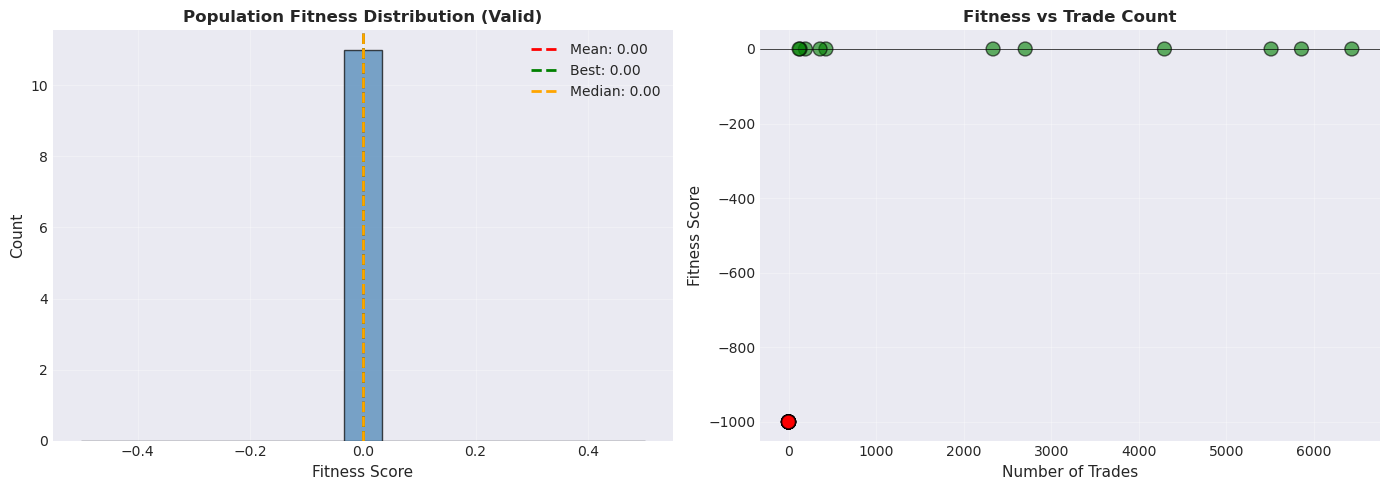

In [10]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 11 — Initialize & evaluate population          ║
# ╚══════════════════════════════════════════════════════╝

# Align data first
ohlcv_aligned = splits['train'].iloc[-len(features_train):].reset_index(drop=True)
features_aligned = features_train.reset_index(drop=True)

pop_size = 30
print(f"Initializing population of {pop_size} chromosomes...\n")

# Initialize without n_assets parameter
population = initialize_population(pop_size=pop_size)

print(f"Evaluating population on {len(features_aligned)} bars...")
fitnesses = []

for i, chromo in enumerate(population):
    # Use fitness_hybrid (Phase 2 features + Phase 1 OHLCV)
    fit = fitness_hybrid(chromo, features_aligned, ohlcv_aligned)
    fitnesses.append(fit)
    
    if (i + 1) % 10 == 0:
        valid_fits = [f for f in fitnesses if f > -999]
        avg_fit = np.mean(valid_fits) if valid_fits else -1000
        print(f"  {i+1}/{pop_size} evaluated (current avg: {avg_fit:.2f})")

fitnesses = np.array(fitnesses)

print("\n" + "="*70)
print("POPULATION STATISTICS")
print("="*70)

# Separate valid and invalid
valid_fits = fitnesses[fitnesses > -999]
invalid_count = len(fitnesses) - len(valid_fits)

print(f"\nPopulation Size: {len(fitnesses)}")
print(f"Valid chromosomes: {len(valid_fits)} ({len(valid_fits)/len(fitnesses)*100:.1f}%)")
print(f"Invalid chromosomes: {invalid_count} ({invalid_count/len(fitnesses)*100:.1f}%)")

if len(valid_fits) > 0:
    print(f"\nFitness Distribution (Valid Only):")
    print(f"  Best:     {valid_fits.max():>8.2f}")
    print(f"  Worst:    {valid_fits.min():>8.2f}")
    print(f"  Average:  {valid_fits.mean():>8.2f}")
    print(f"  Median:   {np.median(valid_fits):>8.2f}")
    print(f"  Std Dev:  {valid_fits.std():>8.2f}")
    
    # Show top 5
    print(f"\nTop 5 Chromosomes:")
    top_indices = np.argsort(fitnesses)[-5:][::-1]
    for rank, idx in enumerate(top_indices, 1):
        chr_stats = population[idx].backtest_stats
        print(f"  {rank}. Fitness: {fitnesses[idx]:>8.2f} | "
              f"Trades: {chr_stats.get('n_trades', 0):>4d} | "
              f"Winrate: {chr_stats.get('winrate', 0):>5.1%}")

else:
    print("\n⚠️  No valid chromosomes found!")
    print("Population is entirely invalid. Check data alignment.")

# ────────────────────────────────────────────────────────
# VISUALIZATION
# ────────────────────────────────────────────────────────

if len(valid_fits) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of valid fitnesses
    ax1.hist(valid_fits, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.axvline(valid_fits.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {valid_fits.mean():.2f}')
    ax1.axvline(valid_fits.max(), color='green', linestyle='--', linewidth=2,
               label=f'Best: {valid_fits.max():.2f}')
    ax1.axvline(np.median(valid_fits), color='orange', linestyle='--', linewidth=2,
               label=f'Median: {np.median(valid_fits):.2f}')
    
    ax1.set_xlabel('Fitness Score', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_title('Population Fitness Distribution (Valid)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Fitness vs Trades scatter
    n_trades = [population[i].backtest_stats.get('n_trades', 0) 
                for i in range(len(population))]
    colors = ['green' if fitnesses[i] > -999 else 'red' for i in range(len(fitnesses))]
    
    ax2.scatter(n_trades, fitnesses, alpha=0.6, s=100, c=colors, edgecolor='black')
    ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Number of Trades', fontsize=11)
    ax2.set_ylabel('Fitness Score', fontsize=11)
    ax2.set_title('Fitness vs Trade Count', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)

else:
    print("\n⚠️  Cannot visualize: no valid chromosomes")

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 12 — Run evolution (5 generations)             ║
# ╚══════════════════════════════════════════════════════╝

# Align data for evolution
ohlcv_aligned = splits['train'].iloc[-len(features_train):].reset_index(drop=True)
features_aligned = features_train.reset_index(drop=True)

print("\n" + "="*70)
print("STARTING EVOLUTION (5 generations)")
print("="*70 + "\n")

# Create wrapper for fitness_hybrid that evolve() can use
def fitness_wrapper(chromo):
    """Wrapper for fitness_hybrid with aligned data"""
    return fitness_hybrid(chromo, features_aligned, ohlcv_aligned)

# Manually run evolution with detailed tracking
pop_size = 30
generations = 20
elite_pct = 0.2
mutation_rate = 0.15
crossover_rate = 0.8
tournament_size = 3

# Initialize population
population = initialize_population(pop_size=pop_size)

history = {
    'best': [],
    'avg': [],
    'std': [],
    'n_trades': [],
    'winrate': []
}

best_ever = None
best_fitness_ever = -np.inf

for gen in range(generations):
    print(f"\n{'='*70}")
    print(f"GENERATION {gen+1}/{generations}")
    print(f"{'='*70}")
    
    # Evaluate population
    print(f"Evaluating {pop_size} chromosomes...")
    fitnesses = []
    
    for i, chromo in enumerate(population):
        fit = fitness_hybrid(chromo, features_aligned, ohlcv_aligned)
        fitnesses.append(fit)
        
        if (i + 1) % 10 == 0:
            valid_fits = [f for f in fitnesses if f > -999]
            avg_fit = np.mean(valid_fits) if valid_fits else -1000
            print(f"  {i+1}/{pop_size} evaluated (avg: {avg_fit:.2f})")
    
    fitnesses = np.array(fitnesses)
    
    # Statistics
    valid_fits = fitnesses[fitnesses > -999]
    if len(valid_fits) > 0:
        best_idx = np.argmax(fitnesses)
        best_gen = population[best_idx]
        best_fit_gen = fitnesses[best_idx]
        
        avg_fit = np.mean(valid_fits)
        std_fit = np.std(valid_fits)
        
        # Track best
        if best_fit_gen > best_fitness_ever:
            best_ever = copy.deepcopy(best_gen)
            best_fitness_ever = best_fit_gen
            print(f"\n🎉 NEW BEST: {best_fitness_ever:.2f}")
        
        history['best'].append(best_fit_gen)
        history['avg'].append(avg_fit)
        history['std'].append(std_fit)
        history['n_trades'].append(best_gen.backtest_stats.get('n_trades', 0))
        history['winrate'].append(best_gen.backtest_stats.get('winrate', 0))
        
        # Print stats
        print(f"\nGeneration Stats:")
        print(f"  Best (this gen):  {best_fit_gen:.2f}")
        print(f"  Best (all-time):  {best_fitness_ever:.2f}")
        print(f"  Average (valid):  {avg_fit:.2f}")
        print(f"  Std Dev:          {std_fit:.2f}")
        print(f"  Valid chromosomes: {len(valid_fits)}/{pop_size}")
        
        print(f"\nBest Chromosome Stats:")
        best_stats = best_gen.backtest_stats
        print(f"  Trades:           {best_stats.get('n_trades', 0)}")
        print(f"  Win Rate:         {best_stats.get('winrate', 0):.1%}")
        print(f"  Expectancy:       {best_stats.get('expectancy', 0):+.4f}")
        print(f"  Sharpe:           {best_stats.get('sharpe', 0):+.2f}")
        print(f"  Max DD:           {best_stats.get('max_dd', 0):+.4f}")
        
    else:
        print("\n⚠️  No valid chromosomes in this generation!")
        history['best'].append(-1000)
        history['avg'].append(-1000)
        history['std'].append(0)
        history['n_trades'].append(0)
        history['winrate'].append(0)
    
    # Selection & Breeding
    if gen < generations - 1:  # Don't breed after last generation
        print(f"\nBreeding new generation...")
        
        elite_count = max(1, int(pop_size * elite_pct))
        elite_indices = np.argsort(fitnesses)[-elite_count:]
        elite = [copy.deepcopy(population[i]) for i in elite_indices]
        
        new_population = elite.copy()
        
        while len(new_population) < pop_size:
            parent1, parent2 = select_parents(population, fitnesses, tournament_size)
            
            if random.random() < crossover_rate:
                child1, child2 = crossover_uniform(parent1, parent2)
                child = random.choice([child1, child2])
            else:
                child = copy.deepcopy(parent1)
            
            child = mutate(child, mutation_rate=mutation_rate)
            child = repair(child)
            
            new_population.append(child)
        
        population = new_population[:pop_size]

print("\n" + "="*70)
print("✓ EVOLUTION COMPLETE!")
print("="*70)

if best_ever:
    print(f"\nBest Chromosome Found:")
    print(f"  Fitness Score:    {best_fitness_ever:.2f}")
    print(f"  Trades:           {best_ever.backtest_stats.get('n_trades', 0)}")
    print(f"  Win Rate:         {best_ever.backtest_stats.get('winrate', 0):.1%}")
    print(f"  Expectancy:       {best_ever.backtest_stats.get('expectancy', 0):+.4f}")
    print(f"  Sharpe:           {best_ever.backtest_stats.get('sharpe', 0):+.2f}")
    print(f"  Max Drawdown:     {best_ever.backtest_stats.get('max_dd', 0):+.4f}")

# ────────────────────────────────────────────────────────
# VISUALIZATION
# ────────────────────────────────────────────────────────

if history['best']:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Fitness over generations
    ax = axes[0, 0]
    ax.plot(history['best'], 'go-', linewidth=2, markersize=8, label='Best')
    ax.fill_between(range(len(history['best'])), 
                     np.array(history['avg']) - np.array(history['std']),
                     np.array(history['avg']) + np.array(history['std']),
                     alpha=0.3, label='±1 Std Dev')
    ax.plot(history['avg'], 'bo--', linewidth=1.5, markersize=6, label='Average')
    ax.set_xlabel('Generation', fontsize=11)
    ax.set_ylabel('Fitness Score', fontsize=11)
    ax.set_title('Fitness Evolution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Trade count over generations
    ax = axes[0, 1]
    ax.plot(history['n_trades'], 'mo-', linewidth=2, markersize=8)
    ax.set_xlabel('Generation', fontsize=11)
    ax.set_ylabel('Number of Trades', fontsize=11)
    ax.set_title('Best Chromosome Trade Count', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Win rate over generations
    ax = axes[1, 0]
    ax.plot([wr*100 for wr in history['winrate']], 'co-', linewidth=2, markersize=8)
    ax.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
    ax.set_xlabel('Generation', fontsize=11)
    ax.set_ylabel('Win Rate (%)', fontsize=11)
    ax.set_title('Best Chromosome Win Rate', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 100])
    
    # Summary stats
    ax = axes[1, 1]
    ax.axis('off')
    
    summary_text = f"""
    EVOLUTION SUMMARY
    {'='*40}
    
    Generations:        {generations}
    Population Size:    {pop_size}
    Initial Best:       {history['best'][0]:.2f}
    Final Best:         {history['best'][-1]:.2f}
    Improvement:        {history['best'][-1] - history['best'][0]:+.2f}
    
    All-Time Best:      {best_fitness_ever:.2f}
    
    Best Trades:        {history['n_trades'][-1]}
    Best Winrate:       {history['winrate'][-1]:.1%}
    
    Parameters:
      Elite %:          {elite_pct*100:.0f}%
      Mutation:         {mutation_rate*100:.0f}%
      Crossover:        {crossover_rate*100:.0f}%
      Tournament:       {tournament_size}
    """
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)


STARTING EVOLUTION (5 generations)


GENERATION 1/20
Evaluating 30 chromosomes...
  10/30 evaluated (avg: 0.00)
  20/30 evaluated (avg: 0.00)
  30/30 evaluated (avg: 0.00)

🎉 NEW BEST: 0.00

Generation Stats:
  Best (this gen):  0.00
  Best (all-time):  0.00
  Average (valid):  0.00
  Std Dev:          0.00
  Valid chromosomes: 14/30

Best Chromosome Stats:
  Trades:           1185
  Win Rate:         0.0%
  Expectancy:       +0.0011
  Sharpe:           +0.00
  Max DD:           +0.0000

Breeding new generation...

GENERATION 2/20
Evaluating 30 chromosomes...
  10/30 evaluated (avg: 0.00)
  20/30 evaluated (avg: 0.00)
  30/30 evaluated (avg: 0.00)

Generation Stats:
  Best (this gen):  0.00
  Best (all-time):  0.00
  Average (valid):  0.00
  Std Dev:          0.00
  Valid chromosomes: 18/30

Best Chromosome Stats:
  Trades:           772
  Win Rate:         0.0%
  Expectancy:       +0.0032
  Sharpe:           +0.00
  Max DD:           +0.0000

Breeding new generation...

GENERATION 3/

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 13 — Visualize evolution                       ║
# ╚══════════════════════════════════════════════════════╝
generations = range(len(history['best']))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fitness over time
ax = axes[0, 0]
ax.plot(generations, history['best'], 'o-', label='Best', linewidth=2.5, markersize=8)
ax.plot(generations, history['avg'], 's-', label='Average', alpha=0.7, markersize=6)
ax.fill_between(
    generations,
    np.array(history['avg']) - np.array(history['std']),
    np.array(history['avg']) + np.array(history['std']),
    alpha=0.2,
    label='±1 std'
)
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Fitness', fontsize=11)
ax.set_title('Fitness Evolution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Improvement per generation
ax = axes[0, 1]
improvement = np.diff(history['best'])
colors = ['green' if x > 0 else 'red' for x in improvement]
ax.bar(generations[1:], improvement, color=colors, alpha=0.6, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Δ Fitness', fontsize=11)
ax.set_title('Improvement per Generation', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Convergence
ax = axes[1, 0]
diversity = np.array(history['best']) - np.array(history['avg'])
ax.plot(generations, diversity, 'o-', color='purple', linewidth=2.5, markersize=8)
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Best - Average', fontsize=11)
ax.set_title('Population Diversity', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Variance
ax = axes[1, 1]
ax.plot(generations, history['std'], 'o-', color='orange', linewidth=2.5, markersize=8)
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Std Dev', fontsize=11)
ax.set_title('Population Variance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEvolution Summary:")
print(f"  Initial best: {history['best'][0]:.2f}")
print(f"  Final best:   {history['best'][-1]:.2f}")
print(f"  Improvement:  {history['best'][-1] - history['best'][0]:+.2f} "
      f"({((history['best'][-1] / history['best'][0]) - 1) * 100:+.1f}%)")

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 14 — Analyze best chromosome                   ║
# ╚══════════════════════════════════════════════════════╝
print("="*70)
print("BEST CHROMOSOME DETAILED ANALYSIS")
print("="*70)

# Direction HEAD
print("\n[DIRECTION HEAD]")
print(f"Threshold: {best_chromo.dir_threshold:.3f}")
active_dirs = [g for g in best_chromo.dir_genes if g.active]
print(f"Active genes: {len(active_dirs)}/5")
for i, gene in enumerate(active_dirs):
    print(f"  {i+1}. Asset {gene.asset}, Feature {gene.feature_id}, "
          f"Lag {gene.lag}, Weight {gene.weight:+.3f}")

# Sequence HEAD
print("\n[SEQUENCE HEAD]")
active_seqs = [g for g in best_chromo.seq_genes if g.active]
print(f"Active genes: {len(active_seqs)}/12")
print("\nTop 5 by entry_price weight magnitude:")
sorted_seqs = sorted(active_seqs, 
                    key=lambda g: abs(g.weights['entry_price']), 
                    reverse=True)[:5]
for i, gene in enumerate(sorted_seqs):
    print(f"  {i+1}. Asset {gene.asset}, Feature {gene.feature_id}, Lag {gene.lag}")
    print(f"     entry_price:  {gene.weights['entry_price']:+.2f}")
    print(f"     target_price: {gene.weights['target_price']:+.2f}")
    print(f"     stop_price:   {gene.weights['stop_price']:+.2f}")

# Confidence HEAD
print("\n[CONFIDENCE HEAD]")
print(f"Risk Base: {best_chromo.risk_base*100:.2f}%")
active_confs = [g for g in best_chromo.conf_genes if g.active]
print(f"Active genes: {len(active_confs)}/5")
for i, gene in enumerate(active_confs):
    print(f"  {i+1}. Asset {gene.asset}, Feature {gene.feature_id}, "
          f"Lag {gene.lag}, Weight {gene.weight:+.3f}")

# Performance
if best_chromo.backtest_stats:
    stats = best_chromo.backtest_stats
    print("\n" + "="*70)
    print("PERFORMANCE METRICS")
    print("="*70)
    print(f"\nTrading Activity:")
    print(f"  Trades:       {stats['n_trades']}")
    print(f"  Winrate:      {stats['winrate']:.1%}")
    print(f"  Avg R:R:      {stats['avg_rr']:.2f}")
    
    print(f"\nPnL:")
    print(f"  Total PnL:    {stats['total_pnl']:.4f}")
    print(f"  Avg Win:      {stats['avg_win']:.4f}")
    print(f"  Avg Loss:     {stats['avg_loss']:.4f}")
    
    print(f"\nRisk:")
    print(f"  Expectancy:   {stats['expectancy']:.4f}")
    print(f"  Sharpe:       {stats['sharpe']:.2f}")
    print(f"  Max DD:       {stats['max_dd']:.4f}")

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 15 — Validation on VAL split                   ║
# ╚══════════════════════════════════════════════════════╝
print("="*70)
print("OUT-OF-SAMPLE VALIDATION")
print("="*70)

print(f"\nTraining fitness: {history['best'][-1]:.2f}")
print(f"Validating on {len(features_val)} unseen validation bars...\n")

val_fitness = fitness(best_chromo, features_val)
val_stats = best_chromo.backtest_stats

print(f"\nValidation fitness: {val_fitness:.2f}")

print("\nComparison:")
train_stats = best_chromo.backtest_stats  # Get fresh stats from training eval
fitness(best_chromo, features_train)  # Refresh
train_stats = best_chromo.backtest_stats

print(f"  Train winrate:    {train_stats.get('winrate', 0):.1%}")
print(f"  Val winrate:      {val_stats.get('winrate', 0):.1%}")
print(f"  Train sharpe:     {train_stats.get('sharpe', 0):.2f}")
print(f"  Val sharpe:       {val_stats.get('sharpe', 0):.2f}")

ratio = val_fitness / history['best'][-1] if history['best'][-1] != 0 else 0
print(f"\nVal/Train ratio: {ratio:.2f}")

if ratio < 0.5:
    print("⚠ WARNING: Significant performance drop (possible overfitting)")
else:
    print("✓ Performance maintained on new data")

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 16 — Test on sacred TEST split                 ║
# ╚══════════════════════════════════════════════════════╝
print("="*70)
print("SACRED TEST SET EVALUATION")
print("="*70)

print(f"\nEvaluating on {len(features_test)} test bars (sacred - out-of-fold)...\n")

test_fitness = fitness(best_chromo, features_test)
test_stats = best_chromo.backtest_stats

print(f"\n" + "="*70)
print("TEST RESULTS (FINAL)")
print("="*70)
print(f"\nFitness Scores:")
print(f"  Train: {history['best'][-1]:.2f}")
print(f"  Val:   {val_fitness:.2f}")
print(f"  Test:  {test_fitness:.2f}  ⚠️  SACRED")

if test_stats:
    print(f"\nTest Metrics:")
    print(f"  Trades:       {test_stats['n_trades']}")
    print(f"  Winrate:      {test_stats['winrate']:.1%}")
    print(f"  Sharpe:       {test_stats['sharpe']:.2f}")
    print(f"  Max DD:       {test_stats['max_dd']:.4f}")
    print(f"  Expectancy:   {test_stats['expectancy']:.4f}")

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 17 — Sample trades                             ║
# ╚══════════════════════════════════════════════════════╝
print("="*70)
print("SAMPLE TRADES FROM BEST CHROMOSOME")
print("="*70)

sample_trades = []

for i in range(min(500, len(features_val) - 120)):
    bar = features_val.iloc[i]
    signal = best_chromo.generate_signal(bar)
    
    if signal:
        sample_trades.append({
            'idx': i,
            'timestamp': features_val.index[i],
            'signal': signal
        })
    
    if len(sample_trades) >= 10:
        break

print(f"\nGenerated {len(sample_trades)} sample trades\n")

for i, trade in enumerate(sample_trades[:5]):
    signal = trade['signal']
    
    print(f"Trade {i+1}: {trade['timestamp']}")
    print(f"  Direction: {'🟢 LONG' if signal.direction == 1 else '🔴 SHORT'}")
    print(f"  Entry:     {signal.sequence['entry']['price']:.5f} "
          f"(in {signal.sequence['entry']['time_expected']} min)")
    print(f"  Target:    {signal.sequence['target']['price']:.5f}")
    print(f"  Stop:      {signal.sequence['stop']['price']:.5f}")
    print(f"  R:R:       {signal.rr:.2f}")
    print(f"  Confidence: {signal.confidence['score']:.2f} "
          f"({signal.confidence['prob_success']:.1%} prob)")
    print()

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 18 — Export best chromosome                    ║
# ╚══════════════════════════════════════════════════════╝
import pickle
import json

# Save pickle
with open('best_chromosome.pkl', 'wb') as f:
    pickle.dump(best_chromo, f)
print("✓ Saved: best_chromosome.pkl")

# Save JSON summary
summary = {
    'timestamp': datetime.now().isoformat(),
    'training_fitness': float(history['best'][-1]),
    'validation_fitness': float(val_fitness),
    'test_fitness': float(test_fitness),
    'generations': len(history['best']),
    'population_size': 30,
    'parameters': {
        'dir_threshold': float(best_chromo.dir_threshold),
        'risk_base': float(best_chromo.risk_base),
        'min_rr': float(best_chromo.min_rr),
        'n_dir_genes': sum(g.active for g in best_chromo.dir_genes),
        'n_seq_genes': sum(g.active for g in best_chromo.seq_genes),
        'n_conf_genes': sum(g.active for g in best_chromo.conf_genes)
    },
    'stats': best_chromo.backtest_stats if best_chromo.backtest_stats else {}
}

with open('best_chromosome_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print("✓ Saved: best_chromosome_summary.json")

# Save history
history_df = pd.DataFrame({
    'generation': range(len(history['best'])),
    'best': history['best'],
    'average': history['avg'],
    'std_dev': history['std']
})
history_df.to_csv('evolution_history.csv', index=False)
print("✓ Saved: evolution_history.csv")

print("\n" + "="*70)
print("PHASE 3 EXPLORATION COMPLETE")
print("="*70)